# Redes Neuronales II — Parte 1
### Rediseño de los modelos con funciones de activación, retropropagación y clasificación binaria

---

**Universidad de Cundinamarca**

**CADI:** Deep Learning — Conceptos

**Estudiante:** Ruby Dayana Cárdenas Gómez

**Docente:** Nidia Stella García Roa

**Repositorio GitHub:** `https://github.com/RubyDayana/redes-neuronales-ii.git`

---

### ¿Qué se hace en este notebook?

En el taller anterior (*Redes Neuronales Básicas*) programé tres modelos desde cero con NumPy y los probé
con compuertas lógicas y con un ejemplo pequeño de estudiantes. En esta segunda parte tomo esos mismos tres
modelos y los **mejoro** para que resuelvan un problema real: decidir entre dos opciones (a eso se le llama
**clasificación binaria**), y además probarlos con datos que la red nunca vio mientras aprendía.

| Aspecto | Taller anterior | Este notebook |
|---|---|---|
| Datos | 4 filas (compuertas), 12 estudiantes inventados | 569 casos reales de diagnóstico médico |
| ¿Con qué se evalúa? | Con los mismos datos con los que aprendió | Con datos guardados aparte, que nunca vio |
| Función de activación de la capa oculta | Sigmoide | Sigmoide **y ReLU** (se comparan las dos) |
| ¿Cómo se mide el error? | Error cuadrático medio (MSE) | Entropía cruzada (se explica más adelante) |
| Retropropagación (backpropagation) | Solo en la red multicapa | También en la red de una capa |

Las redes se programan solo con **Python y NumPy**, igual que antes. scikit-learn se usa únicamente para
cargar los datos y matplotlib para hacer las gráficas.

---
## 1. Los datos: diagnóstico de tumores de mama

Uso el conjunto de datos **Breast Cancer Wisconsin**, uno de los más usados para aprender a clasificar.
Tiene 569 casos reales. Cada caso es un tumor descrito con 30 medidas que se tomaron de una imagen
(qué tan grande es, qué tan irregular es su borde, qué textura tiene, etc.) y una respuesta: si el tumor
resultó ser **benigno (1)** o **maligno (0)**.

Es un problema de **clasificación binaria** porque solo hay dos respuestas posibles: benigno o maligno.
Es la misma idea del taller anterior de "aprueba / no aprueba", pero con datos reales y muchas más medidas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

np.random.seed(42)   # para que los resultados no cambien cada vez que se ejecuta

datos = load_breast_cancer()
X_todo = datos.data          # 569 filas x 30 columnas
Y_todo = datos.target        # 0 = maligno, 1 = benigno

print("Forma de X:", X_todo.shape, "->", X_todo.shape[0], "casos con", X_todo.shape[1], "medidas cada uno")
print("Forma de Y:", Y_todo.shape)
print()
print("Casos benignos (1):", np.sum(Y_todo == 1))
print("Casos malignos (0):", np.sum(Y_todo == 0))
print()
print("Primeras 5 medidas del primer caso:", np.round(X_todo[0, :5], 2))
print("Nombres de esas medidas:", [str(n) for n in datos.feature_names[:5]])

Forma de X: (569, 30) -> 569 casos con 30 medidas cada uno
Forma de Y: (569,)

Casos benignos (1): 357
Casos malignos (0): 212

Primeras 5 medidas del primer caso: [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.200e-01]
Nombres de esas medidas: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']


### 1.1. Separar entrenamiento y prueba

Esta es la primera mejora importante. En el taller anterior la red se probaba con los mismos datos con los
que había aprendido, y eso es como darle a un estudiante el examen con las mismas preguntas que estudió: saca
100 % pero no sabemos si entendió o si se las memorizó.

Por eso ahora los datos se parten en dos: el **80 %** se usa para que la red aprenda y el **20 %** se guarda
escondido para preguntarle al final y ver qué tan bien responde con casos que nunca vio.

In [2]:
def dividir(X, Y, proporcion_prueba=0.2):
    """Revuelve los datos al azar y separa una parte para la prueba final."""
    n = X.shape[0]
    indices = np.random.permutation(n)          # los numeros del 0 al n-1 en orden revuelto
    n_prueba = int(n * proporcion_prueba)
    idx_prueba, idx_entreno = indices[:n_prueba], indices[n_prueba:]
    return X[idx_entreno], Y[idx_entreno], X[idx_prueba], Y[idx_prueba]

X_ent, Y_ent, X_pru, Y_pru = dividir(X_todo, Y_todo)

print("Entrenamiento:", X_ent.shape[0], "casos")
print("Prueba       :", X_pru.shape[0], "casos")

Entrenamiento: 456 casos
Prueba       : 113 casos


### 1.2. Normalizar las medidas

Las 30 medidas vienen en escalas muy diferentes: el área de un tumor puede valer 1 000 mientras que la
suavidad vale 0.1. Si se dejan así, la red pensaría que el área importa mil veces más solo por ser un número
grande. Es el mismo problema de las horas de estudio (0 a 10) y la asistencia (0 a 100) del taller anterior.

En el taller anterior dividí por el máximo. Esta vez uso una forma un poco mejor: a cada columna le resto su
promedio y la divido por qué tanto se dispersan sus valores (la desviación estándar). El resultado es que
todas las columnas quedan alrededor de 0 y más o menos del mismo tamaño.

Un detalle: el promedio y la desviación se calculan **solo con los datos de entrenamiento**. Los datos de prueba
están "escondidos", así que no se pueden usar ni para esto.

In [3]:
promedio   = X_ent.mean(axis=0)
desviacion = X_ent.std(axis=0)

X_ent = (X_ent - promedio) / desviacion
X_pru = (X_pru - promedio) / desviacion

# Las etiquetas se convierten en columna, que es la forma que esperan las redes
Y_ent = Y_ent.reshape(-1, 1)
Y_pru = Y_pru.reshape(-1, 1)

print("Después de normalizar, cada columna de entrenamiento tiene:")
print("  promedio ~", np.round(X_ent.mean(), 4), " y desviación ~", np.round(X_ent.std(), 4))
print("Forma final de X_ent:", X_ent.shape, " Y_ent:", Y_ent.shape)

Después de normalizar, cada columna de entrenamiento tiene:
  promedio ~ -0.0  y desviación ~ 1.0
Forma final de X_ent: (456, 30)  Y_ent: (456, 1)


In [4]:
def exactitud(predicciones, Y):
    """Porcentaje de aciertos. Como la red responde con decimales (0.87, 0.12...), primero se redondea a 0 o 1."""
    return np.mean(np.round(predicciones) == Y) * 100


def matriz_confusion(predicciones, Y, titulo):
    """Tabla que muestra EN QUE se equivoca el modelo: cuantos malignos dijo que eran benignos, y al reves."""
    p = np.round(predicciones).astype(int).ravel()
    y = Y.astype(int).ravel()
    vp = np.sum((p == 1) & (y == 1)); fn = np.sum((p == 0) & (y == 1))
    fp = np.sum((p == 1) & (y == 0)); vn = np.sum((p == 0) & (y == 0))
    print(f"\n{titulo}")
    print("                      Predijo maligno   Predijo benigno")
    print(f"  Realmente maligno        {vn:4d}              {fp:4d}")
    print(f"  Realmente benigno        {fn:4d}              {vp:4d}")
    print(f"  Exactitud: {exactitud(predicciones, Y):.2f} %")

---
## 2. Funciones de activación

Recordemos: una neurona multiplica sus entradas por los pesos, suma todo y le agrega el sesgo. Ese resultado
se llama `z`. La **función de activación** es la que toma ese `z` y decide **qué responde finalmente la neurona**.

En el taller anterior usé dos: escalón y sigmoide. Aquí agrego una tercera, la **ReLU**, que es la que más se
usa hoy en día en Deep Learning.

| Función | Qué hace con z | Qué responde | En palabras sencillas |
|---|---|---|---|
| **Escalón** | Si z es 0 o más responde 1, si no responde 0 | Solo 0 o 1 | Un interruptor: prendido o apagado, sin puntos medios |
| **Sigmoide** | σ(z) = 1 / (1 + e^-z) | Un número entre 0 y 1 | "Qué tan segura estoy": 0.9 es muy segura de que sí, 0.1 muy segura de que no |
| **ReLU** | Si z es negativo responde 0, si es positivo responde z tal cual | 0 o cualquier número positivo | "Si es negativo lo ignoro, si es positivo lo dejo pasar" |

### ¿Por qué no basta con el escalón?

Para que la red aprenda con retropropagación hay que poder responder esta pregunta: *"si muevo un poquito la
entrada de la neurona, ¿cuánto se mueve su salida?"*. A esa cantidad se le llama **derivada**.

- Con el **escalón** no se puede responder: la salida está quieta en 0 o en 1 y de repente salta. Por eso el
  perceptrón no puede usar retropropagación.
- Con la **sigmoide** sí se puede, pero tiene un detalle: la salida se mueve muy poquito (como máximo 0.25) y en
  los extremos casi no se mueve. Cuando el error tiene que viajar hacia atrás por varias capas, se va
  "apagando" en cada una.
- Con la **ReLU** la respuesta es 1 en todo el lado positivo: la salida se mueve exactamente lo mismo que la
  entrada. El error viaja hacia atrás sin perder fuerza. Por eso las redes con ReLU aprenden más rápido.

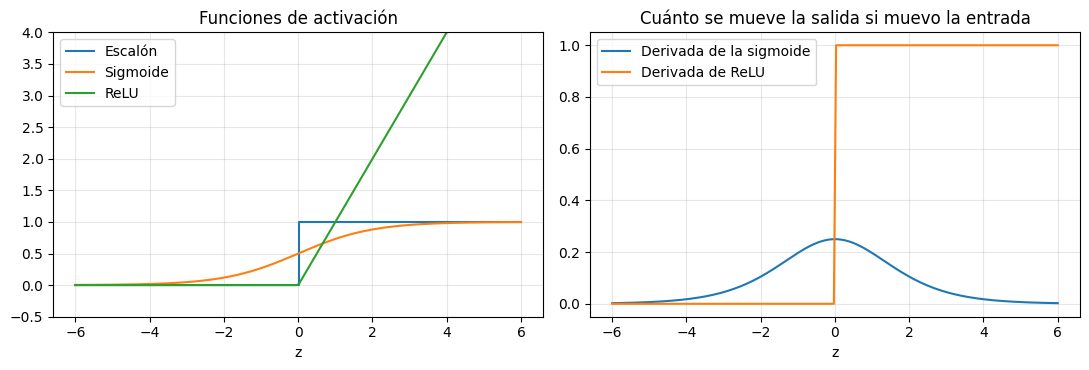

Observa: la sigmoide nunca pasa de 0.25 y se apaga en los extremos; la ReLU vale 1 en todo el lado positivo.


In [5]:
def escalon(z):
    return np.where(z >= 0, 1, 0)

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def derivada_sigmoide(a):
    # Se calcula a partir de lo que respondio la neurona ('a'), no de 'z'
    return a * (1 - a)

def relu(z):
    return np.maximum(0, z)

def derivada_relu(z):
    # 1 donde z fue positivo, 0 donde fue negativo
    return np.where(z > 0, 1.0, 0.0)


# Gráfica de las tres funciones y de las dos derivadas
z = np.linspace(-6, 6, 200)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8))

ejes[0].plot(z, escalon(z), label="Escalón", drawstyle="steps-post")
ejes[0].plot(z, sigmoide(z), label="Sigmoide")
ejes[0].plot(z, relu(z), label="ReLU")
ejes[0].set_title("Funciones de activación"); ejes[0].set_xlabel("z"); ejes[0].legend(); ejes[0].grid(alpha=.3)
ejes[0].set_ylim(-0.5, 4)

ejes[1].plot(z, derivada_sigmoide(sigmoide(z)), label="Derivada de la sigmoide")
ejes[1].plot(z, derivada_relu(z), label="Derivada de ReLU")
ejes[1].set_title("Cuánto se mueve la salida si muevo la entrada"); ejes[1].set_xlabel("z"); ejes[1].legend(); ejes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Observa: la sigmoide nunca pasa de 0.25 y se apaga en los extremos; la ReLU vale 1 en todo el lado positivo.")

---
## 3. Perceptrón rediseñado

Es exactamente el mismo perceptrón del taller anterior: una sola neurona con función escalón, que cuando se
equivoca corrige sus pesos con la regla `w = w + lr · (esperado − obtenido) · x`. Solo cambian dos cosas:

1. Ahora recibe **30 entradas** (las 30 medidas del tumor) en lugar de 2.
2. Aprende con los datos de entrenamiento y se le **pregunta con los de prueba**.

Como usa la función escalón, este modelo **no puede usar retropropagación** (acabamos de ver por qué). Se
queda con su regla de siempre y sirve como punto de comparación para lo que viene.

In [6]:
def entrenar_perceptron(X, Y, lr=0.01, epocas=50):
    n_entradas = X.shape[1]
    W = np.random.uniform(-0.5, 0.5, size=n_entradas)
    b = 0.0
    historial = []

    for epoca in range(epocas):
        errores = 0
        for entrada, esperado in zip(X, Y.ravel()):
            obtenido = escalon(np.dot(entrada, W) + b)
            error = esperado - obtenido
            W = W + lr * error * entrada
            b = b + lr * error
            errores += int(error != 0)
        historial.append(errores)
        if errores == 0:
            break
    return W, b, historial


def predecir_perceptron(X, W, b):
    return escalon(X @ W + b).reshape(-1, 1)


np.random.seed(42)
W_p, b_p, hist_p = entrenar_perceptron(X_ent, Y_ent, lr=0.01, epocas=50)

print(f"Errores por época (primeras 10): {hist_p[:10]}")
print(f"Errores en la última época      : {hist_p[-1]} de {X_ent.shape[0]}")
print()
print(f"Exactitud en ENTRENAMIENTO: {exactitud(predecir_perceptron(X_ent, W_p, b_p), Y_ent):.2f} %")
print(f"Exactitud en PRUEBA       : {exactitud(predecir_perceptron(X_pru, W_p, b_p), Y_pru):.2f} %")
matriz_confusion(predecir_perceptron(X_pru, W_p, b_p), Y_pru, "Matriz de confusión del perceptrón (datos de prueba)")

Errores por época (primeras 10): [36, 19, 17, 11, 12, 12, 10, 9, 13, 10]
Errores en la última época      : 12 de 456

Exactitud en ENTRENAMIENTO: 98.46 %
Exactitud en PRUEBA       : 97.35 %

Matriz de confusión del perceptrón (datos de prueba)
                      Predijo maligno   Predijo benigno
  Realmente maligno          41                 1
  Realmente benigno           2                69
  Exactitud: 97.35 %


El perceptrón lo hace bastante bien, porque en este problema los tumores benignos y malignos se pueden
separar casi con una sola línea recta. Pero fíjate en dos cosas: los errores por época **suben y bajan** sin
terminar de estabilizarse (el perceptrón corrige a golpes, no poco a poco), y solo responde 0 o 1, sin decir
qué tan seguro está.

---
## 4. Red de una capa con retropropagación

En el taller anterior la red de una capa ya usaba la sigmoide y corregía sus pesos midiendo el error con el
error cuadrático medio (MSE). Ahora la **mejoro** en tres cosas:

**1. Una mejor forma de medir el error: la entropía cruzada.**
El MSE castiga todos los errores por igual. La entropía cruzada castiga muchísimo más cuando la red está
*muy segura y se equivoca*. Por ejemplo, si dice "99 % seguro que es benigno" y era maligno, el castigo es
enorme; si dice "55 % benigno" y era maligno, el castigo es pequeño. Tiene sentido: equivocarse con mucha
confianza es peor. Por eso es la medida que se usa para clasificar.

$$L = -\frac{1}{n}\sum \left[\, y \cdot \log(a) + (1-y) \cdot \log(1-a) \,\right]$$

(No hace falta memorizar la fórmula; lo importante es la idea de arriba).

**2. Retropropagación, aunque sea una sola capa.**
El proceso es el mismo de siempre: la red responde, se mide el error y se lleva **hacia atrás** para saber
cuánto debe moverse cada peso. Con sigmoide + entropía cruzada la cuenta queda muy limpia: la "culpa" de la
neurona es simplemente *lo que respondió menos lo que debía responder* (`a − y`).

**3. Aprender por grupos pequeños (mini-lotes).**
Antes la red veía los 456 casos, calculaba el error y corregía los pesos **una vez** por época. Ahora los mira
en grupos de 32, y corrige después de cada grupo. Es como estudiar por capítulos en vez de leer el libro
entero antes de repasar: aprende más rápido con menos épocas.

In [7]:
def entropia_cruzada(A, Y):
    eps = 1e-9   # un numero minusculo para no calcular log(0), que no existe
    return -np.mean(Y * np.log(A + eps) + (1 - Y) * np.log(1 - A + eps))


def lotes(X, Y, tamano):
    """Revuelve los datos y los va entregando en grupos pequenos de 'tamano' ejemplos."""
    indices = np.random.permutation(X.shape[0])
    for i in range(0, X.shape[0], tamano):
        idx = indices[i:i + tamano]
        yield X[idx], Y[idx]


def entrenar_capa(X, Y, lr=0.1, epocas=100, tamano_lote=32, mostrar_cada=20):
    n_entradas = X.shape[1]
    W = np.random.uniform(-0.1, 0.1, size=(n_entradas, 1))
    b = np.zeros((1, 1))
    historial = []

    for epoca in range(1, epocas + 1):
        for X_l, Y_l in lotes(X, Y, tamano_lote):
            # 1) HACIA ADELANTE
            Z = X_l @ W + b
            A = sigmoide(Z)

            # 2) HACIA ATRAS (retropropagacion en una capa)
            delta = A - Y_l                              # culpa de la neurona: lo que dijo menos lo que debia decir
            grad_W = X_l.T @ delta / X_l.shape[0]        # cuanto y hacia donde mover cada peso
            grad_b = np.mean(delta, axis=0, keepdims=True)

            # 3) CORREGIR (se resta porque queremos que el error BAJE)
            W -= lr * grad_W
            b -= lr * grad_b

        costo = entropia_cruzada(sigmoide(X @ W + b), Y)
        historial.append(costo)
        if epoca % mostrar_cada == 0 or epoca == 1:
            print(f"  Época {epoca:4d} -> error (entropía cruzada): {costo:.4f}")

    return W, b, historial


np.random.seed(42)
print("Entrenando la red de una capa:")
W_c, b_c, hist_c = entrenar_capa(X_ent, Y_ent, lr=0.1, epocas=100)

pred_c_ent = sigmoide(X_ent @ W_c + b_c)
pred_c_pru = sigmoide(X_pru @ W_c + b_c)
print()
print(f"Exactitud en ENTRENAMIENTO: {exactitud(pred_c_ent, Y_ent):.2f} %")
print(f"Exactitud en PRUEBA       : {exactitud(pred_c_pru, Y_pru):.2f} %")
matriz_confusion(pred_c_pru, Y_pru, "Matriz de confusión de la red de una capa (datos de prueba)")

Entrenando la red de una capa:
  Época    1 -> error (entropía cruzada): 0.2102
  Época   20 -> error (entropía cruzada): 0.0783
  Época   40 -> error (entropía cruzada): 0.0674
  Época   60 -> error (entropía cruzada): 0.0622
  Época   80 -> error (entropía cruzada): 0.0591
  Época  100 -> error (entropía cruzada): 0.0568

Exactitud en ENTRENAMIENTO: 98.68 %
Exactitud en PRUEBA       : 99.12 %

Matriz de confusión de la red de una capa (datos de prueba)
                      Predijo maligno   Predijo benigno
  Realmente maligno          41                 1
  Realmente benigno           0                71
  Exactitud: 99.12 %


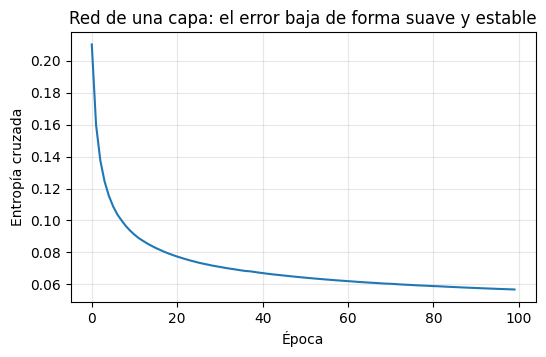

Ejemplos de lo que responde la red (probabilidad de ser benigno):
  Probabilidad  89.95 %   ->  Real: benigno
  Probabilidad   0.00 %   ->  Real: maligno
  Probabilidad   0.21 %   ->  Real: maligno
  Probabilidad  99.94 %   ->  Real: benigno
  Probabilidad 100.00 %   ->  Real: benigno
  Probabilidad   0.00 %   ->  Real: maligno


In [8]:
plt.figure(figsize=(6, 3.5))
plt.plot(hist_c)
plt.title("Red de una capa: el error baja de forma suave y estable")
plt.xlabel("Época"); plt.ylabel("Entropía cruzada"); plt.grid(alpha=.3)
plt.show()

print("Ejemplos de lo que responde la red (probabilidad de ser benigno):")
for prob, real in list(zip(pred_c_pru.ravel(), Y_pru.ravel()))[:6]:
    print(f"  Probabilidad {prob*100:6.2f} %   ->  Real: {'benigno' if real == 1 else 'maligno'}")

A diferencia del perceptrón, aquí el error **baja suavemente** en cada época, sin brincos, y la red entrega
un porcentaje de confianza y no solo un sí o un no. Eso es lo que gana uno al cambiar el escalón por una
función que sí se puede derivar.

---
## 5. Red multicapa: sigmoide contra ReLU

Ahora tomo la red multicapa del taller anterior (la clase `Capa`, la función `adelante` y el entrenamiento
con retropropagación) y la **mejoro** para que a cada capa se le pueda decir qué función de activación usar.
Con eso construyo dos redes del mismo tamaño y las pongo a competir:

```
   Red A (como antes):   30 entradas -> 16 ocultas [sigmoide] -> 1 salida [sigmoide]
   Red B (rediseñada):   30 entradas -> 16 ocultas [ReLU]     -> 1 salida [sigmoide]
```

La neurona de salida es sigmoide en las dos, porque el problema es de sí/no y queremos un porcentaje de
confianza. Lo único que cambia es la capa del medio.

### Retropropagación con varias capas, paso a paso

1. **Neurona de salida:** su culpa es `a − y`, igual que en la red de una capa.
2. **Capa oculta:** no sabemos directamente su error, así que se estima: cada neurona oculta tiene tanta culpa
   como peso tenía su conexión con la neurona de salida que se equivocó. Ese reparto se multiplica por
   "cuánto se mueve su salida si se mueve su entrada" (la derivada). **Aquí es donde importa la función:** con
   sigmoide ese número es pequeño y la culpa llega debilitada; con ReLU es 1 y llega completa.
3. **Corrección:** cada peso se mueve un pasito en la dirección que reduce su culpa.

In [9]:
class Capa:
    """Una capa de la red. Igual que antes guarda pesos y sesgos, pero ahora tambien sabe que activacion usar."""
    def __init__(self, n_entradas, n_neuronas, activacion):
        self.activacion = activacion
        # Pesos iniciales al azar, pero mas pequenos mientras mas entradas tenga la capa.
        # Si arrancan muy grandes, la sigmoide se va a los extremos (donde ya no aprende)
        # y la ReLU produce numeros gigantes. Con esta escala arrancan "en zona segura".
        escala = np.sqrt(2.0 / n_entradas) if activacion == "relu" else np.sqrt(1.0 / n_entradas)
        self.W = np.random.randn(n_entradas, n_neuronas) * escala
        self.b = np.zeros((1, n_neuronas))

    def activar(self, z):
        return relu(z) if self.activacion == "relu" else sigmoide(z)

    def derivada(self, z, a):
        return derivada_relu(z) if self.activacion == "relu" else derivada_sigmoide(a)


def crear_red(topologia, activacion_oculta):
    """topologia = [30, 16, 1] -> 30 entradas, 16 ocultas, 1 salida. Las ocultas usan activacion_oculta; la salida siempre sigmoide."""
    red = []
    for i in range(len(topologia) - 1):
        es_ultima = (i == len(topologia) - 2)
        red.append(Capa(topologia[i], topologia[i + 1], "sigmoide" if es_ultima else activacion_oculta))
    return red


def adelante(red, X):
    """Pasa los datos por la red. Guarda las sumas (Z) y las respuestas (A) de cada capa: ambas hacen falta al ir hacia atras."""
    Zs, As = [], [X]
    a = X
    for capa in red:
        z = a @ capa.W + capa.b
        a = capa.activar(z)
        Zs.append(z); As.append(a)
    return Zs, As


def predecir(red, X):
    return adelante(red, X)[1][-1]

In [10]:
def entrenar_red(red, X, Y, X_val, Y_val, lr=0.05, epocas=100, tamano_lote=32, mostrar_cada=20):
    """Entrena con retropropagacion. En cada epoca anota el error con los datos de entrenamiento Y con los de prueba."""
    historial = {"entreno": [], "prueba": []}

    for epoca in range(1, epocas + 1):
        for X_l, Y_l in lotes(X, Y, tamano_lote):
            n = X_l.shape[0]

            # ---------- 1) HACIA ADELANTE ----------
            Zs, As = adelante(red, X_l)

            # ---------- 2) HACIA ATRÁS ----------
            deltas = [None] * len(red)
            deltas[-1] = As[-1] - Y_l                                 # culpa de la neurona de salida
            for i in reversed(range(len(red) - 1)):                   # se reparte la culpa hacia atras, capa por capa
                deltas[i] = (deltas[i + 1] @ red[i + 1].W.T) * red[i].derivada(Zs[i], As[i + 1])

            # ---------- 3) CORREGIR ----------
            for i, capa in enumerate(red):
                capa.W -= lr * (As[i].T @ deltas[i]) / n
                capa.b -= lr * np.mean(deltas[i], axis=0, keepdims=True)

        historial["entreno"].append(entropia_cruzada(predecir(red, X), Y))
        historial["prueba"].append(entropia_cruzada(predecir(red, X_val), Y_val))
        if epoca % mostrar_cada == 0 or epoca == 1:
            print(f"  Época {epoca:4d} -> error entreno: {historial['entreno'][-1]:.4f}   "
                  f"error prueba: {historial['prueba'][-1]:.4f}")
    return historial

### 5.1. Red A: capa oculta con sigmoide (como en el taller anterior)

In [11]:
np.random.seed(42)
red_sig = crear_red([30, 16, 1], activacion_oculta="sigmoide")
print("Entrenando la red multicapa con SIGMOIDE en la capa oculta:")
hist_sig = entrenar_red(red_sig, X_ent, Y_ent, X_pru, Y_pru, lr=0.05, epocas=100)

pred_sig = predecir(red_sig, X_pru)
print()
print(f"Exactitud en ENTRENAMIENTO: {exactitud(predecir(red_sig, X_ent), Y_ent):.2f} %")
print(f"Exactitud en PRUEBA       : {exactitud(pred_sig, Y_pru):.2f} %")
matriz_confusion(pred_sig, Y_pru, "Matriz de confusión - Red A (sigmoide)")

Entrenando la red multicapa con SIGMOIDE en la capa oculta:
  Época    1 -> error entreno: 0.5414   error prueba: 0.5441
  Época   20 -> error entreno: 0.1574   error prueba: 0.1394
  Época   40 -> error entreno: 0.1022   error prueba: 0.0893
  Época   60 -> error entreno: 0.0832   error prueba: 0.0743
  Época   80 -> error entreno: 0.0738   error prueba: 0.0683
  Época  100 -> error entreno: 0.0680   error prueba: 0.0646

Exactitud en ENTRENAMIENTO: 98.25 %
Exactitud en PRUEBA       : 98.23 %

Matriz de confusión - Red A (sigmoide)
                      Predijo maligno   Predijo benigno
  Realmente maligno          41                 1
  Realmente benigno           1                70
  Exactitud: 98.23 %


### 5.2. Red B: capa oculta con ReLU (rediseño)

In [12]:
np.random.seed(42)
red_relu = crear_red([30, 16, 1], activacion_oculta="relu")
print("Entrenando la red multicapa con ReLU en la capa oculta:")
hist_relu = entrenar_red(red_relu, X_ent, Y_ent, X_pru, Y_pru, lr=0.05, epocas=100)

pred_relu = predecir(red_relu, X_pru)
print()
print(f"Exactitud en ENTRENAMIENTO: {exactitud(predecir(red_relu, X_ent), Y_ent):.2f} %")
print(f"Exactitud en PRUEBA       : {exactitud(pred_relu, Y_pru):.2f} %")
matriz_confusion(pred_relu, Y_pru, "Matriz de confusión - Red B (ReLU)")

Entrenando la red multicapa con ReLU en la capa oculta:


  Época    1 -> error entreno: 0.3218   error prueba: 0.3243
  Época   20 -> error entreno: 0.0785   error prueba: 0.0834


  Época   40 -> error entreno: 0.0564   error prueba: 0.0758
  Época   60 -> error entreno: 0.0470   error prueba: 0.0725
  Época   80 -> error entreno: 0.0404   error prueba: 0.0709
  Época  100 -> error entreno: 0.0352   error prueba: 0.0699

Exactitud en ENTRENAMIENTO: 99.34 %
Exactitud en PRUEBA       : 98.23 %

Matriz de confusión - Red B (ReLU)
                      Predijo maligno   Predijo benigno
  Realmente maligno          40                 2
  Realmente benigno           0                71
  Exactitud: 98.23 %


### 5.3. Comparación visual del aprendizaje

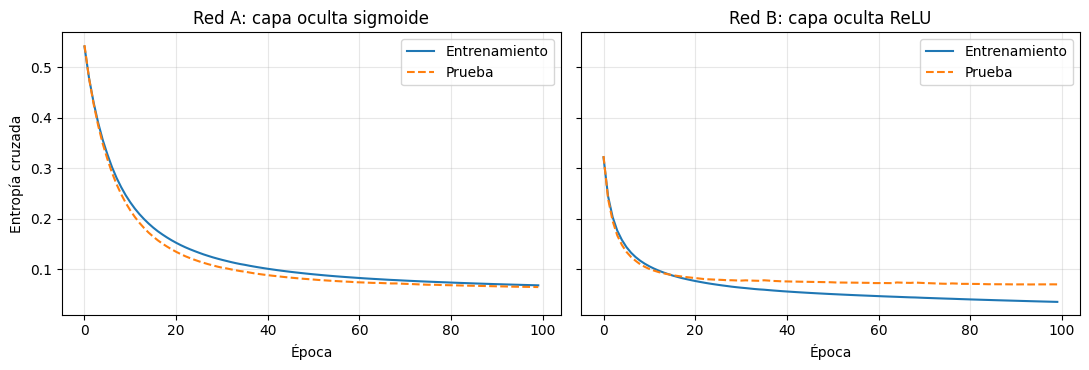

Épocas para bajar de 0.10 de error -> Sigmoide: 42   ReLU: 13


In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)

ejes[0].plot(hist_sig["entreno"], label="Entrenamiento")
ejes[0].plot(hist_sig["prueba"], label="Prueba", linestyle="--")
ejes[0].set_title("Red A: capa oculta sigmoide")
ejes[0].set_xlabel("Época"); ejes[0].set_ylabel("Entropía cruzada"); ejes[0].legend(); ejes[0].grid(alpha=.3)

ejes[1].plot(hist_relu["entreno"], label="Entrenamiento")
ejes[1].plot(hist_relu["prueba"], label="Prueba", linestyle="--")
ejes[1].set_title("Red B: capa oculta ReLU")
ejes[1].set_xlabel("Época"); ejes[1].legend(); ejes[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

# ¿En qué época cada red bajó por primera vez de 0.10 de error?
def epoca_umbral(h, umbral=0.10):
    for i, v in enumerate(h, start=1):
        if v < umbral:
            return i
    return None

print(f"Épocas para bajar de 0.10 de error -> Sigmoide: {epoca_umbral(hist_sig['entreno'])}   "
      f"ReLU: {epoca_umbral(hist_relu['entreno'])}")

Las curvas lo dicen todo: la red con **ReLU** baja el error mucho más rápido en las primeras épocas, porque
la culpa llega completa a la capa oculta. La red con **sigmoide** también aprende, pero arranca más despacio.

Otra cosa buena: las líneas punteadas (datos de prueba) van pegadas a las continuas (entrenamiento). Eso
significa que las dos redes están **entendiendo** el patrón y no memorizando las respuestas. Si estuvieran
memorizando, la línea de prueba se despegaría hacia arriba.

---
## 6. Comparación de todos los modelos

Modelo                             Entrenamiento     Prueba
------------------------------------------------------------
Perceptrón (escalón)                     98.46 %    97.35 %
Red de una capa (sigmoide)               98.68 %    99.12 %
Red multicapa A (sigmoide)               98.25 %    98.23 %
Red multicapa B (ReLU)                   99.34 %    98.23 %


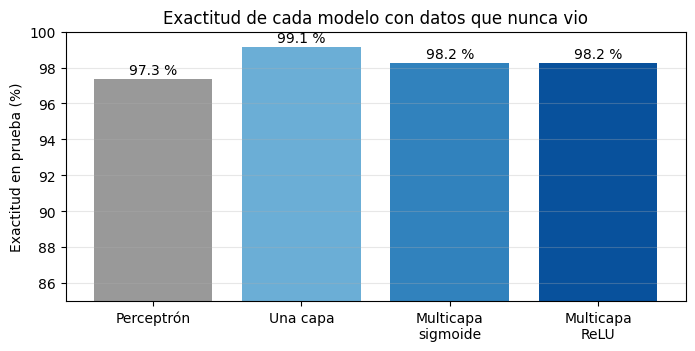

In [14]:
resultados = [
    ("Perceptrón (escalón)",            predecir_perceptron(X_ent, W_p, b_p), predecir_perceptron(X_pru, W_p, b_p)),
    ("Red de una capa (sigmoide)",      pred_c_ent,                          pred_c_pru),
    ("Red multicapa A (sigmoide)",      predecir(red_sig, X_ent),            pred_sig),
    ("Red multicapa B (ReLU)",          predecir(red_relu, X_ent),           pred_relu),
]

print(f"{'Modelo':32s} {'Entrenamiento':>15s} {'Prueba':>10s}")
print("-" * 60)
for nombre, p_ent, p_pru in resultados:
    print(f"{nombre:32s} {exactitud(p_ent, Y_ent):13.2f} % {exactitud(p_pru, Y_pru):8.2f} %")

# Gráfica de barras
nombres = [r[0] for r in resultados]
ex_pru  = [exactitud(r[2], Y_pru) for r in resultados]
plt.figure(figsize=(8, 3.5))
barras = plt.bar(range(4), ex_pru, color=["#999", "#6baed6", "#3182bd", "#08519c"])
plt.xticks(range(4), ["Perceptrón", "Una capa", "Multicapa\nsigmoide", "Multicapa\nReLU"])
plt.ylim(85, 100); plt.ylabel("Exactitud en prueba (%)")
plt.title("Exactitud de cada modelo con datos que nunca vio")
for b_, v in zip(barras, ex_pru):
    plt.text(b_.get_x() + b_.get_width()/2, v + 0.3, f"{v:.1f} %", ha="center")
plt.grid(axis="y", alpha=.3); plt.show()

Los cuatro modelos quedan muy parecidos (todos por encima del 97 %). Esto pasa porque en estos datos los
tumores benignos y malignos se pueden separar casi con una línea recta, y hasta el perceptrón puede con eso.
La diferencia entre los modelos no está tanto en el número final sino en **cómo llegan a él**: qué tan rápido
bajan el error, si entregan un porcentaje de confianza y si aprenden de forma estable. Esa diferencia se va a
notar muchísimo más en MNIST (los dígitos escritos a mano), donde una línea recta no alcanza.

---
## 7. Conclusiones

1. **Guardar datos aparte cambia la forma de evaluar.** En el taller anterior los modelos sacaban 100 % porque
   se probaban con lo mismo que habían estudiado. Ahora el número que importa es el de los datos de prueba,
   porque es el que dice si el modelo sirve con casos nuevos.

2. **El perceptrón tiene un límite.** Funciona, pero como usa la función escalón no puede usar retropropagación,
   corrige a saltos y no dice qué tan seguro está.

3. **Para retropropagar hay que poder derivar.** Cambiar el escalón por la sigmoide fue lo que permitió que
   el error bajara suavemente, sin brincos.

4. **La entropía cruzada es la forma correcta de medir el error al clasificar.** Castiga con fuerza las
   respuestas muy seguras y equivocadas, algo que el error cuadrático medio no hacía.

5. **ReLU aprende más rápido que la sigmoide en las capas ocultas.** Con la misma red, la misma tasa de
   aprendizaje y las mismas épocas, la red con ReLU bajó el error en un tercio de las épocas, porque la culpa
   llega completa hacia atrás. Por eso ReLU es la que se usa por defecto en Deep Learning, y es la que voy a
   usar en los notebooks de MNIST con Keras y PyTorch.

6. **Todo esto sigue siendo NumPy.** Entender estas piezas (activaciones, derivadas, culpa de cada capa,
   grupos pequeños) es lo que permite después usar TensorFlow y PyTorch sabiendo qué están haciendo por dentro.